<a href="https://colab.research.google.com/github/jasminef19/MyTelkomsel/blob/main/WEEK3/WEEK3_EDA_mytsel_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WEEK 3 EDA for Google Apps Review
irma@its.ac.id/ PBA 2025

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd

# Define file path
file_path = "/content/df_mytselrev_50kNew.csv"

# Read the Excel file (only if the file exists)
df_mytselrev = pd.read_csv(file_path)

# Display the first few rows
df_mytselrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8013d176-fdf1-4fc6-9b23-cec2cd1c4754,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak sekali bos,5,0,9.1.0,2026-03-04 15:42:04,NaN,NaN,9.1.0
1,1291c18e-5cb4-409b-bd82-e0a34c1aca98,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bagus,5,0,9.1.0,2026-03-04 15:40:51,NaN,NaN,9.1.0
2,b88af38a-f45e-4436-908c-d1873c79e841,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cerdas.cepat,5,0,9.1.0,2026-03-04 15:40:38,NaN,NaN,9.1.0
3,6987e130-a70d-495f-bc68-4d01945e14b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan gak stabil mending pake kartu lain aj...,1,0,6.12.2,2026-03-04 15:38:19,"Hai Kak Jax, Mohon maaf untuk ketidaknyamanann...",2026-03-04 16:08:26,6.12.2
4,7b084aa2-6a1b-4f21-baa6-ee5e80079c89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jelek sumpah jaringan tsel ini !! PARAH BANGET...,1,0,9.1.0,2026-03-04 15:37:11,"Hai Kak Resya, Mohon maaf untuk ketidaknyamana...",2026-03-04 16:24:17,9.1.0


# Exploratory Data Analysis (EDA) of JKN Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [2]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords
Downloading the Indonesian stopwords from NLTK for text processing.
```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

In [4]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
!pip install Sastrawi

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


# Create stemmer and lemmatizer objects
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Case lowering
    text = text.lower()

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Stemming
    text = stemmer.stem(text)

    # Lemmatization (requires a part-of-speech tag for optimal results, using 'v' for verb as a default)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, 'v') for word in words]
    text = ' '.join(lemmatized_words)

    return text

# Apply the cleaning function to the 'review' column
df_mytselrev['cleaned_review'] = df_mytselrev['content'].apply(clean_text)

# Display the DataFrame with the cleaned reviews
print(df_mytselrev[['content', 'cleaned_review']])


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                                 content  \
0                                      banyak sekali bos   
1                                           sangat bagus   
2                                           cerdas.cepat   
3      jaringan gak stabil mending pake kartu lain aj...   
4      Jelek sumpah jaringan tsel ini !! PARAH BANGET...   
...                                                  ...   
49995                   sangat mudah dan sangat membantu   
49996                                  tanpa bonus parah   
49997  gak guna ni aplikasi tidak berguna...!!! jgn d...   
49998  sinyal nya min diperbaiki lagi , susah banget ...   
49999  tolong perbaiki pitur jaga pulsa,saya sudah ak...   

                                          cleaned_review  
0                                      banyak sekali bos  
1                                           sangat bagus  
2                                            cerdascepat  
3      jar gak stabil mend pake kartu lie a

## 5. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.
```python
# Convert 'at' column to datetime format
df_jknrev['at'] = pd.to_datetime(df_jknrev['at'])

# Display dataset info and first few rows
df_jknrev.info()
df_jknrev.head()
```

In [7]:
# Convert 'at' column to datetime format
df_mytselrev['at'] = pd.to_datetime(df_mytselrev['at'])

# Display dataset info and first few rows
df_mytselrev.info()
df_mytselrev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0    reviewId             50000 non-null  object        
 1   userName              50000 non-null  object        
 2   userImage             50000 non-null  object        
 3   content               50000 non-null  object        
 4   score                 50000 non-null  int64         
 5   thumbsUpCount         50000 non-null  int64         
 6   reviewCreatedVersion  42622 non-null  object        
 7   at                    50000 non-null  datetime64[ns]
 8   replyContent          28390 non-null  object        
 9   repliedAt             28390 non-null  object        
 10  appVersion            42622 non-null  object        
 11  cleaned_review        50000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 4.6+ MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,8013d176-fdf1-4fc6-9b23-cec2cd1c4754,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak sekali bos,5,0,9.1.0,2026-03-04 15:42:04,NaN,NaN,9.1.0,banyak sekali bos
1,1291c18e-5cb4-409b-bd82-e0a34c1aca98,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bagus,5,0,9.1.0,2026-03-04 15:40:51,NaN,NaN,9.1.0,sangat bagus
2,b88af38a-f45e-4436-908c-d1873c79e841,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cerdas.cepat,5,0,9.1.0,2026-03-04 15:40:38,NaN,NaN,9.1.0,cerdascepat
3,6987e130-a70d-495f-bc68-4d01945e14b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan gak stabil mending pake kartu lain aj...,1,0,6.12.2,2026-03-04 15:38:19,"Hai Kak Jax, Mohon maaf untuk ketidaknyamanann...",2026-03-04 16:08:26,6.12.2,jar gak stabil mend pake kartu lie aj mahal do...
4,7b084aa2-6a1b-4f21-baa6-ee5e80079c89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jelek sumpah jaringan tsel ini !! PARAH BANGET...,1,0,9.1.0,2026-03-04 15:37:11,"Hai Kak Resya, Mohon maaf untuk ketidaknyamana...",2026-03-04 16:24:17,9.1.0,jelek sumpah jar tsel ini parah banget ga huja...


## 6. Missing Values Analysis
Identifies and counts missing values in each column.
```python
missing_values = df_jknrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)
```

In [8]:
missing_values = df_mytselrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
 reviewId                   0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     7378
at                          0
replyContent            21610
repliedAt               21610
appVersion               7378
cleaned_review              0
dtype: int64


## 7. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.
```python
plt.figure(figsize=(8,5))
sns.countplot(x=df_jknrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
```

Visualizing the distribution of review scores to understand user sentiments.

/tmp/ipykernel_3465/3969038670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_mytselrev['score'], palette="viridis")


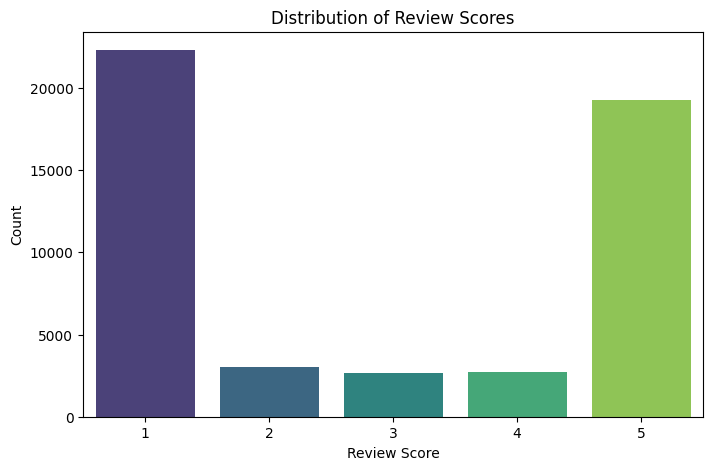

In [11]:
## 7. Review Score Distribution
plt.figure(figsize=(8,5))
sns.countplot(x=df_mytselrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## 8. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.
```python
# Extract review date
df_jknrev['review_date'] = df_jknrev['at'].dt.date
review_trend = df_jknrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()
```

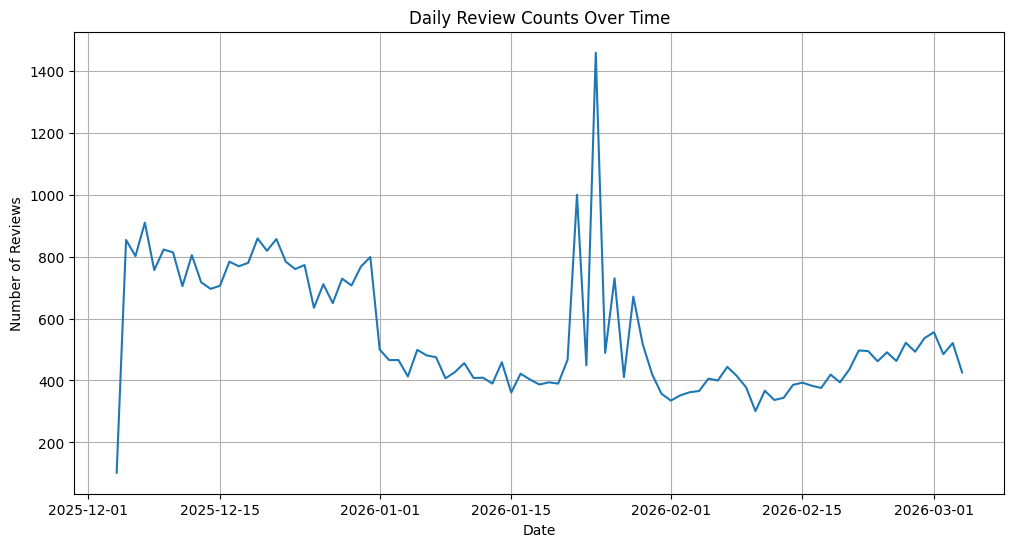

In [12]:
# Extract review date
df_mytselrev['review_date'] = df_mytselrev['at'].dt.date
review_trend = df_mytselrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [14]:
## 9. Word Frequency Analysis
#Analyzing common words in reviews, excluding Indonesian stopwords.

stop_words = set(stopwords.words('indonesian'))

# Combine all review text
all_reviews = " ".join(df_mytselrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)


Most Common Words in Reviews:
         Word  Frequency
0       mahal       9194
1   telkomsel       8808
2       paket       8303
3         nya       7137
4    jaringan       6923
5    aplikasi       6323
6       bagus       5407
7      sinyal       5156
8       harga       4839
9        beli       4833
10      kuota       4830
11      lemot       4237
12        aja       3922
13        gak       3725
14         ga       3464
15     banget       3311
16       udah       3015
17         yg       2955
18      jelek       2806
19   internet       2775
